# Actividad — Sesión 3: Del dato crudo al dataset listo
### Ingestión y preparación de datos · Inteligencia Artificial (FP13)
**Nombre:** Chelsea Nicole Merryman Gonzalez  **Matrícula:** 4709857  **Fecha:** 6 de septiembre de 2026

---
### Instrucciones
Trabajas con los **mismos 4 archivos** de la clase (`flota_norteamerica.csv`, `flota_europa.xlsx`,
`flota_asia.txt`, `flota_datalake.parquet`), que deben estar en la **misma carpeta** que este
notebook. Completa cada bloque marcado con `# TODO`. Responde también las **preguntas de análisis**
(celdas de texto). 

**Entrega (hoy mismo):** sube a *Canvas* el link de github a este notebook ejecutado (menú *Kernel → Restart &
Run All* sin errores) con nombre `S3_ApellidoNombre.ipynb`.

**Objetivo:** dejar el dataset **consolidado, limpio y enriquecido** para responder la pregunta:
*¿qué características del powertrain determinan el consumo (L/100 km) de un vehículo?*


## Librerías

In [17]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme(style='whitegrid')

## Parte 1 · Ingestión y consolidación  *(2 pts)*
Lee cada archivo con la función adecuada y únelos en un solo DataFrame `df`.
Recuerda: el TXT usa separador `~` y marca los faltantes con `?`.

In [18]:
# TODO: lee las 4 fuentes
df_csv = pd.read_csv('flota_norteamerica.csv')
df_xls = pd.read_excel('flota_europa.xlsx', sheet_name='registros')
df_txt = pd.read_csv('flota_asia.txt', sep='~', na_values='?')
df_pq  = pd.read_parquet('flota_datalake.parquet')

# TODO: consolida en un solo DataFrame
df = pd.concat([df_csv, df_xls, df_txt, df_pq], ignore_index=True)

print('Consolidado ->', df.shape)   # se espera (410, 9)

Consolidado -> (410, 9)


## Parte 2 · Limpieza básica  *(2 pts)*
1. Reporta cuántos **duplicados** hay y elimínalos.
2. Reporta cuántos **faltantes** hay en `horsepower` e **imputa** con la mediana.

In [19]:
# TODO: duplicados
print('Duplicados:', df.duplicated().sum())          # df.duplicated().sum()
df = df.drop_duplicates().reset_index(drop=True)                            # df.drop_duplicates().reset_index(drop=True)

# TODO: faltantes en horsepower
print('Faltantes horsepower:', df['horsepower'].isna().sum())
df['horsepower'] = df['horsepower'].fillna(df['horsepower'].median())      # imputa con la mediana

print('Filas finales:', len(df), '| Faltantes HP:', df['horsepower'].isna().sum())

Duplicados: 12
Faltantes horsepower: 6
Filas finales: 398 | Faltantes HP: 0


## Parte 3 · Mapeos y unidades métricas  *(1.5 pts)*
1. Crea la columna `region` mapeando `origin` (1=EUA, 2=Europa, 3=Japón).
2. Crea `peso_kg` (1 lb = 0.453592 kg).
3. Crea `consumo_L_100km` a partir de `mpg` (fórmula: `235.215 / mpg`).

In [20]:
# TODO: región
df['region'] = df['origin'].map({1: 'EUA', 2: 'Europa', 3: 'Japon'})       # df['origin'].map({...})

# TODO: peso en kg
df['peso_kg'] = (df['weight']   * 0.453592).round(1)

# TODO: consumo en L/100km
df['consumo_L_100km'] = (235.215 / df['mpg']).round(2)

df[['name', 'region', 'peso_kg', 'consumo_L_100km']].head()

,name,region,peso_kg,consumo_L_100km
0,chevrolet chevelle malibu,EUA,1589.4,13.07
1,buick skylark 320,EUA,1675.1,15.68
2,plymouth satellite,EUA,1558.5,13.07
3,amc rebel sst,EUA,1557.2,14.70
4,ford torino,EUA,1564.4,13.84


## Parte 4 · Extracción e ingeniería de características  *(2 pts)*
1. Extrae la **marca** (primer token de `name`). Corrige al menos: `chevy`/`chevroelt`→`chevrolet`,
   `toyouta`→`toyota`, `vw`/`vokswagen`→`volkswagen`.
2. Crea la característica `relacion_pot_peso` = `horsepower / peso_kg`.
3. **Diseña tú una característica nueva** con sentido automotriz (por ejemplo, peso por cilindro,
   una bandera `es_importado`, etc.) y explícala en la celda de texto.

In [21]:
# TODO: marca normalizada
correcciones = {'chevroelt': 'chevrolet', 'chevy': 'chevrolet', 'maxda': 'mazda',
    'toyouta': 'toyota', 'vw': 'volkswagen', 'vokswagen': 'volkswagen',
    'mercedes-benz': 'mercedes'}             # completa el diccionario
df['marca'] = df['name'].str.split().str[0].replace(correcciones)                  # df['name'].str.split().str[0].replace(correcciones)

# TODO: relación potencia-peso
df['relacion_pot_peso'] = (df['horsepower'] / df['peso_kg']).round(4)

# TODO: TU característica nueva
df['mi_feature'] = (df['displacement'] * 0.0163871).round(2) ### es el displacement de pulgadas cubicas a litros

df[['name', 'marca', 'relacion_pot_peso', 'mi_feature']].head()

,name,marca,relacion_pot_peso,mi_feature
0,chevrolet chevelle malibu,chevrolet,0.0818,5.03
1,buick skylark 320,buick,0.0985,5.74
2,plymouth satellite,plymouth,0.0962,5.21
3,amc rebel sst,amc,0.0963,4.98
4,ford torino,ford,0.0895,4.95


**✍️ Explica tu característica nueva** (2–3 líneas: qué mide y por qué podría ayudar a predecir el consumo):

El displacement es el volumen que desplaza los pistones dentro de los cilindros durante su recorrido. Esto podria ayudar a predecir el consumo ya que un motor con mayor cilindrada puede admitir y quemar mas volumen por ciclo.

## Parte 5 · Análisis de correlación  *(2 pts)*
1. Calcula la matriz de correlación de las variables numéricas relevantes.
2. Grafica el **mapa de calor**.
3. Identifica un **par altamente correlacionado** (`|r| > 0.9`) y decide cuál conservar.

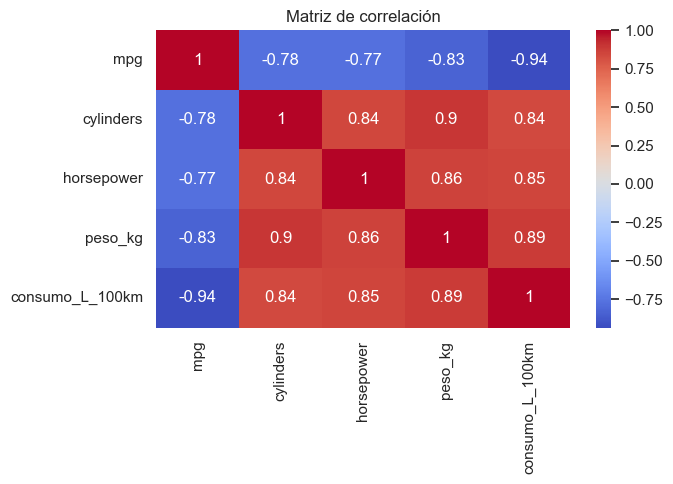

In [22]:
num = ['mpg', 'cylinders', 'horsepower', 'peso_kg', 'consumo_L_100km']   # puedes ajustar
corr = df[num].corr()                         # df[num].corr()

# TODO: mapa de calor con seaborn (usa annot=True, cmap='coolwarm')
plt.figure(figsize=(7, 5))
sns.heatmap(corr,annot=True,cmap='coolwarm')                                # sns.heatmap(...)
plt.title('Matriz de correlación')
plt.tight_layout()
plt.show()

**✍️ Pregunta de análisis:** menciona **un par** de variables con `|r| > 0.9`, indica cuál
**eliminarías** y **justifica** por qué (2–3 líneas):

Las variables con mas de 0.9 son mpg y consumo L_100km. Eliminaria mpg, ya que ambas variables son el consumo de combustible simplementa estan en unidades de medicion distintas, y considero que es mejor conservar el consumo L_100km.

## Cierre  *(reporte, 0.5 pts)*
Muestra la forma final del dataset y sus columnas.

In [23]:
print('Dataset final:', df.shape)
print('Columnas:', list(df.columns))
df.head()

Dataset final: (398, 15)
Columnas: ['mpg', 'cylinders', 'displacement', 'horsepower', 'weight', 'acceleration', 'model_year', 'origin', 'name', 'region', 'peso_kg', 'consumo_L_100km', 'marca', 'relacion_pot_peso', 'mi_feature']


,mpg,cylinders,displacement,horsepower,weight,acceleration,model_year,origin,name,region,peso_kg,consumo_L_100km,marca,relacion_pot_peso,mi_feature
0,18.0,8,307.0,130.0,3504,12.0,70,1,chevrolet chevelle malibu,EUA,1589.4,13.07,chevrolet,0.0818,5.03
1,15.0,8,350.0,165.0,3693,11.5,70,1,buick skylark 320,EUA,1675.1,15.68,buick,0.0985,5.74
2,18.0,8,318.0,150.0,3436,11.0,70,1,plymouth satellite,EUA,1558.5,13.07,plymouth,0.0962,5.21
3,16.0,8,304.0,150.0,3433,12.0,70,1,amc rebel sst,EUA,1557.2,14.70,amc,0.0963,4.98
4,17.0,8,302.0,140.0,3449,10.5,70,1,ford torino,EUA,1564.4,13.84,ford,0.0895,4.95


---
### Rúbrica (10 pts)
| Parte | Criterio | Pts |
|---|---|---|
| 1 | Lee los 4 formatos correctamente y consolida (410 filas) | 2.0 |
| 2 | Elimina 12 duplicados e imputa faltantes con mediana | 2.0 |
| 3 | Mapeos de región y conversiones métricas correctas | 1.5 |
| 4 | Marca normalizada + feature propia con justificación | 2.0 |
| 5 | Heatmap correcto + par redundante bien justificado | 2.0 |
| Cierre | Notebook corre completo sin errores (*Run All*) | 0.5 |
| | **Total** | **10** |

<br>

> Se evalúa que el notebook **corra de principio a fin sin errores** y que las **respuestas de
> análisis** estén redactadas con criterio de ingeniería.
